In [15]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json


from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)


In [16]:

X_test = np.load(r"C:\Users\4m\Documents\GitHub\Drowsiness-Project\feature_extraction\extracted_features\X_test_features.npy")

y_test = np.load(r"C:\Users\4m\Documents\GitHub\Drowsiness-Project\feature_extraction\extracted_features\y_test.npy")

In [17]:
x_train = np.load(r"C:\Users\4m\Documents\GitHub\Drowsiness-Project\feature_extraction\extracted_features\X_train_features.npy")

y_train = np.load(r"C:\Users\4m\Documents\GitHub\Drowsiness-Project\feature_extraction\extracted_features\y_train.npy")

In [18]:
scaler = joblib.load(r"C:\Users\4m\Documents\GitHub\Drowsiness-Project\feature_extraction\extracted_features\scaler.pkl")

c:\Users\4m\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
X_test = scaler.transform(X_test)

In [20]:
model = joblib.load(r"C:\Users\4m\Documents\GitHub\Drowsiness-Project\model\svm_model.pkl")

c:\Users\4m\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [21]:
y_pred = model.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


Accuracy: 0.9832974137931034


In [ ]:
report = classification_report(y_test, y_pred)

print("\nClassification Report:\n")

print(report)


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2831
           1       0.99      0.98      0.98      2737

    accuracy                           0.98      5568
   macro avg       0.98      0.98      0.98      5568
weighted avg       0.98      0.98      0.98      5568



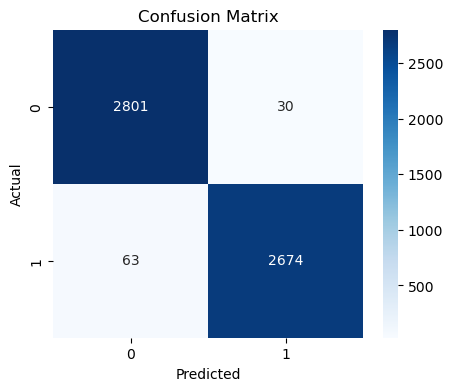

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()

In [26]:
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

In [27]:

classification_error = (FP + FN) / float(TP + TN + FP + FN)

print('Classification error : {0:0.4f}'.format(classification_error))

Classification error : 0.0167


In [28]:

precision = TP / float(TP + FP)


print('Precision : {0:0.4f}'.format(precision))

Precision : 0.9894


In [29]:
recall = TP / float(TP + FN)

print('Recall or Sensitivity : {0:0.4f}'.format(recall))

Recall or Sensitivity : 0.9780


In [30]:
true_positive_rate = TP / float(TP + FN)


print('True Positive Rate : {0:0.4f}'.format(true_positive_rate))

True Positive Rate : 0.9780


In [31]:
false_positive_rate = FP / float(FP + TN)


print('False Positive Rate : {0:0.4f}'.format(false_positive_rate))

False Positive Rate : 0.0111


In [32]:
specificity = TN / (TN + FP)

print('Specificity : {0:0.4f}'.format(specificity))

Specificity : 0.9889


In [33]:

classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)

print('Classification accuracy : {0:0.4f}'.format(classification_accuracy))

Classification accuracy : 0.9833


In [34]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print('Confusion matrix\n\n', cm)

print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[2801   30]
 [  63 2674]]

True Positives(TP) =  2801

True Negatives(TN) =  2674

False Positives(FP) =  30

False Negatives(FN) =  63


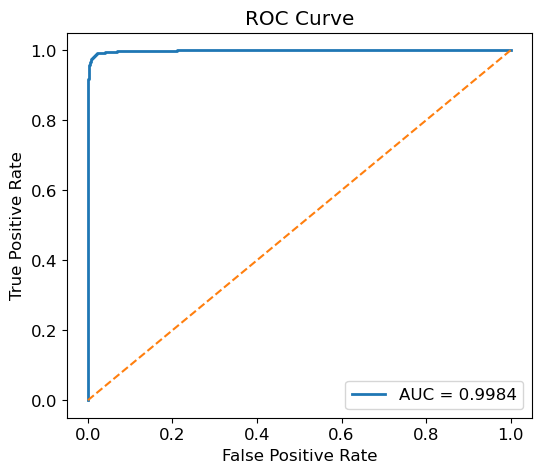


ROC AUC Score: 0.9984


In [38]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

if hasattr(model, "predict_proba"):
    y_scores = model.predict_proba(X_test)[:, 1]
else:
    y_scores = model.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

roc_auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.savefig("roc_curve.png")

plt.show()

print(f"\nROC AUC Score: {roc_auc:.4f}")

In [ ]:
from sklearn.metrics import roc_auc_score

ROC_AUC = roc_auc_score(y_test, y_pred)

print('ROC AUC : {:.4f}'.format(ROC_AUC))

ROC AUC : 0.9832


In [47]:
y_pred_train = model.predict(x_train)

In [48]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.9284


In [53]:
print('Test-set accuracy score: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))

Test-set accuracy score: 0.9833


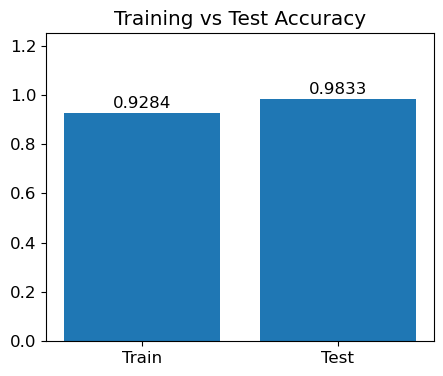

In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(5,4))

plt.bar(["Train", "Test"], [train_acc, test_acc])

plt.title("Training vs Test Accuracy")
plt.ylim(0, 1.25)

for i, v in enumerate([train_acc, test_acc]):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center')

plt.show()

In [49]:
print('Training set score: {:.4f}'.format(model.score(x_train, y_train)))

Training set score: 0.9284


In [40]:
print('Test set score: {:.4f}'.format(model.score(X_test, y_test)))

Test set score: 0.9833


In [43]:
import pandas as pd

pd.Series(y_test).value_counts()

0    2831
1    2737
Name: count, dtype: int64

In [42]:
import numpy as np

np.unique(y_test, return_counts=True)

(array([0, 1]), array([2831, 2737], dtype=int64))

In [44]:
null_accuracy = (85/(85+55))

print('Null accuracy score: {0:0.4f}'. format(null_accuracy))

Null accuracy score: 0.6071
